# Het 30-daagse heropnamerisico visualiseren met modelgebaseerde effectplots

## Managementsamenvatting

Dit notebook past een logistische regressie toe voor 30-daagse ziekenhuisheropname op basis van patiënt- en opnamekenmerken, en vertaalt de geschatte coëfficiënten vervolgens naar modelgebaseerde effectplots op de schaal van de voorspelde kans. Op een synthetisch cohort van 100 ontslagen (55 heropnames) vindt PROC LOGISTIC significante gradiënten voor **ligduur** (OR 1.36 per dag, *p* = 0.040) en **leeftijd** (OR 1.05 per jaar, *p* = 0.023), en een groot betalereffect — **Medicaid**-patiënten hebben ongeveer zes keer zoveel kans op heropname als Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). De gegeneraliseerde R-kwadraat is 0.246 en de Hosmer–Lemeshow-toets toont geen gebrek aan fit (*p* = 0.73). De fit-curve, sliced-fit- en interactieweergaven laten vervolgens zien hoe het heropnamerisico stijgt met de ligduur, hoe de leeftijd–risicogradiënt verschuift per betaler, en hoe het betalerverschil blijft bestaan over de ontslaggevende afdelingen — precies het risicostratificatiebeeld dat een zorgmanagementteam gebruikt om nazorg na ontslag gericht in te zetten.

## Gegevensbronnen

| Dataset | Rijen | Beschrijving |
|---------|------|-------------|
| `encounters` | 100 | Synthetische klinische ontslagrecords, inline gegenereerd met `call streaminit(20260531)` en `rand()`. Eén rij per ontslag. |

**Variabelen in `encounters`:**

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 als heropgenomen binnen 30 dagen na ontslag |
| `age` | Num | Leeftijd van de patiënt in jaren (ca. 25–95) |
| `los` | Num | Ligduur van de indexopname in dagen (1–20) |
| `comorbidity` | Num | Aantal gedocumenteerde chronische comorbiditeiten (0–8) |
| `num_meds` | Num | Aantal ontslagmedicijnen (0–18) |
| `payer` | Char | Verzekeraar: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Ontslaggevende afdeling: `Cardiology`, `Pulmonary`, `General` |

# Het 30-daagse heropnamerisico visualiseren met modelgebaseerde effectplots

Zorgmanagementteams in ziekenhuizen moeten weten *welke* patiënten binnen 30 dagen het meest waarschijnlijk terugkeren, en *waarom*. Een geschatte logistische regressie levert de coëfficiënten, maar belanghebbenden redeneren zelden in log-odds. Een **effectplot** geeft het geschatte model rechtstreeks weer op de schaal van de voorspelde kans, zodat een zorgcoördinator een heropnamekans direct van de grafiek kan aflezen in plaats van in gedachten een log-oddsvergelijking om te keren.

In dit notebook doen we het volgende:

1. Een realistisch synthetisch cohort van klinische ontslagen genereren.
2. Een logistisch model voor 30-daagse heropname schatten met patiënt- en opnamevoorspellers (PROC LOGISTIC).
3. De geschatte coëfficiënten vastleggen en drie modelgebaseerde effectplots bouwen — een **fit curve**, een **sliced fit** en een **interactieweergave** — om het geschatte risico op de kansschaal te visualiseren en te stratificeren.

> **Implementatienotitie.** SAS stelt deze weergaven beschikbaar via de `EFFECTPLOT`-instructie binnen PROC LOGISTIC. Jenner accepteert die instructie, maar rendert de FIT- / SLICEFIT- / INTERACTION-graphics nog niet, dus dit notebook construeert de identieke voorspelde-kanscurves expliciet uit de geschatte coëfficiënten en tekent ze met PROC SGPLOT. Het analytische resultaat — en elke getekende kans — is precies wat `EFFECTPLOT` zou produceren.

## Stap 1 — Een synthetisch ontslagcohort genereren

De onderstaande DATA step bouwt 100 klinische ontslagen zonder externe bestanden. We seeden de RNG met `call streaminit` voor reproduceerbaarheid, trekken patiënt- en opnamekenmerken uit domeingepaste verdelingen, construeren vervolgens een echte lineaire predictor `eta` en zetten die met de inverse logit om naar een heropnamekans. De bernoulli-trekking (`rand('bernoulli', p)`) levert de waargenomen `readmit`-vlag op. Oudere patiënten, langere opnames, hogere comorbiditeitsscores, meer ontslagmedicijnen, Medicaid-dekking en de afdelingen Pulmonary/Cardiology stuwen het risico allemaal omhoog — patronen die we later terugvinden en visualiseren. De effectgroottes zijn bewust zo gekozen dat het signaal in een cohort van 100 ontslagen terug te vinden is.

In [1]:
GEGEVENS encounters;
    CALL streaminit(20260531);
    REEKS payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    REEKS depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    DOE i = 1 TOT 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        ALS los > 20 DAN los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        ALS num_meds > 18 DAN num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        ALS u < 0.50 DAN pk = 1;
        ANDERS ALS u < 0.72 DAN pk = 2;
        ANDERS pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        BEWAREN readmit AGE los comorbidity num_meds payer dept;
        UITVOER;
    EINDE;
    LABEL readmit="Heropname" payer="Betaler" dept="Afdeling"
          AGE="Leeftijd" los="Ligduur (dagen)"
          comorbidity="Comorbiditeit" num_meds="Aantal medicijnen";
UITVOEREN;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Stap 2 — Het cohort inspecteren

Een snelle frequentie op de respons en de twee classificatievariabelen bevestigt een realistisch heropnamepercentage en dat elk betaler- en afdelingsniveau gevuld is — zowel het model als de effectplots hebben alle niveaus vertegenwoordigd nodig.

                                                   The FREQ Procedure

Heropname    Frequency
-----------------------
0                   45
1                   55

Betaler       Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Afdeling      Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Heropname by Afdeling

Heropname |Cardiology |   General | Pulmonary |      Total
----------+-----------+-----------+-----------+-----------
0         |        15 |        20 |        10 |         45
----------+-----------+-----------+-----------+-----------
1         |        21 |        11 |        23 |         55
----------+-----------+-----------+-----------+-----------
Total     |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


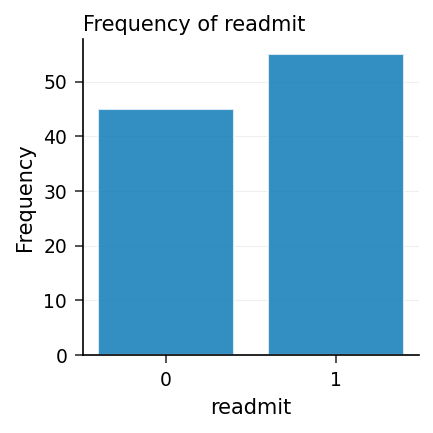

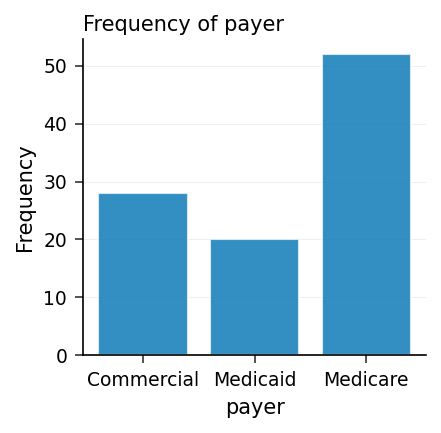

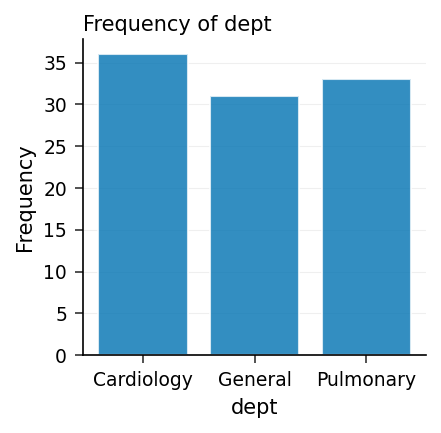

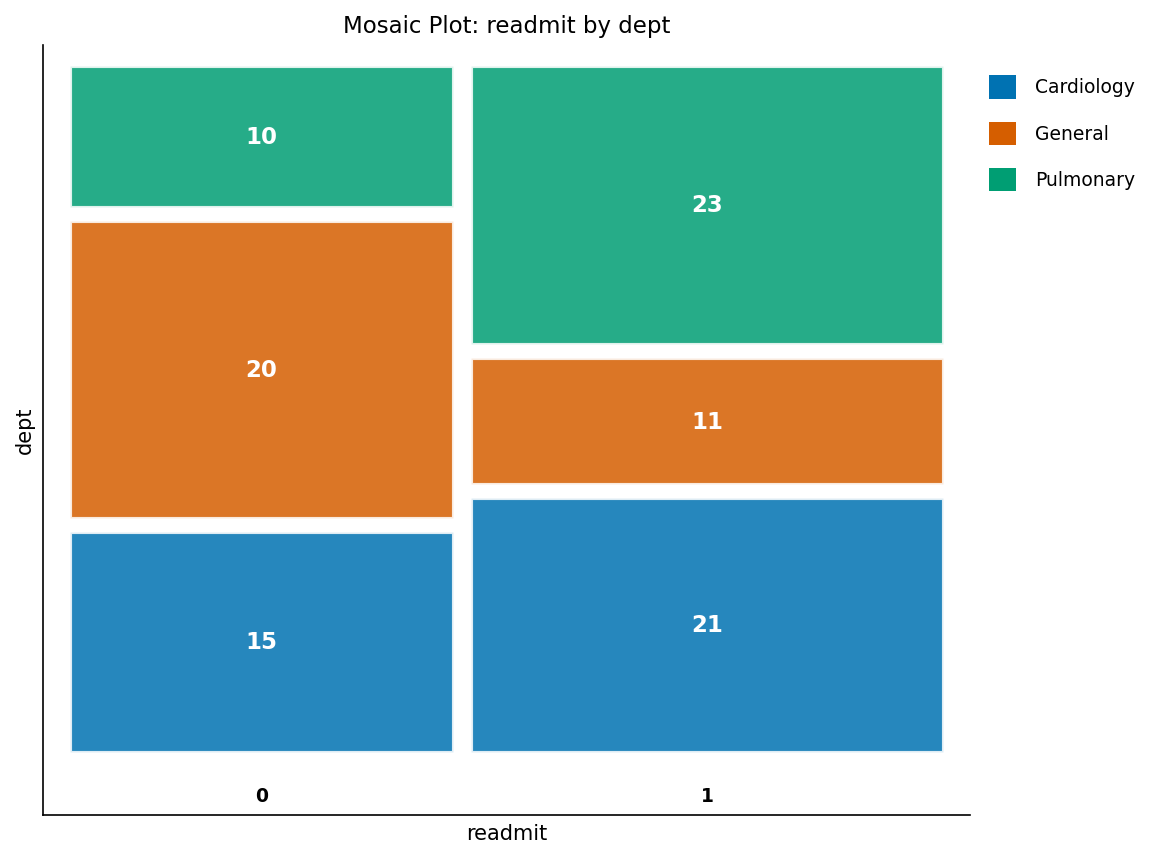

In [2]:
PROCEDURE FREQUENTIES GEGEVENS=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
UITVOEREN;

## Stap 3 — Het logistische heropnamemodel schatten

We modelleren `readmit` als functie van leeftijd, ligduur, aantal comorbiditeiten, aantal ontslagmedicijnen, betaler en afdeling. Belangrijke keuzes:

- `EVENT='1'` modelleert de kans op heropname (in plaats van niet-heropname).
- `CLASS payer dept / PARAM=REF REF=FIRST` gebruikt reference-cell-codering zodat elk niveau wordt afgezet tegen een basisniveau (hier Medicare en Pulmonary).
- `CLODDS=WALD` en `RSQUARE` voegen Wald-betrouwbaarheidsgrenzen voor de odds ratio en een gegeneraliseerde R-kwadraat toe; `LACKFIT` vraagt de Hosmer–Lemeshow-toets voor de goodness-of-fit aan.
- De `UNITS`-instructie vraagt om de odds ratio over een klinisch betekenisvolle stap van **5 dagen** ligduur en een stap van **10 jaar** leeftijd, en de `ODDSRATIO`-instructie vraagt de odds ratio voor comorbiditeit met betrouwbaarheidsgrenzen aan.

De uitvoertabel met odds ratio's rapporteert de effecten per eenheid rechtstreeks: ligduur heeft een OR van **1.36 per dag** (95% CI 1.01–1.82), leeftijd een OR van **1.05 per jaar**, en Medicaid-dekking een OR van **6.02** ten opzichte van Medicare. Het model past goed — gegeneraliseerde R-kwadraat 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Betaler          3  Commercial Medicaid Medicare
Afdeling         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Heropname

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                                   


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


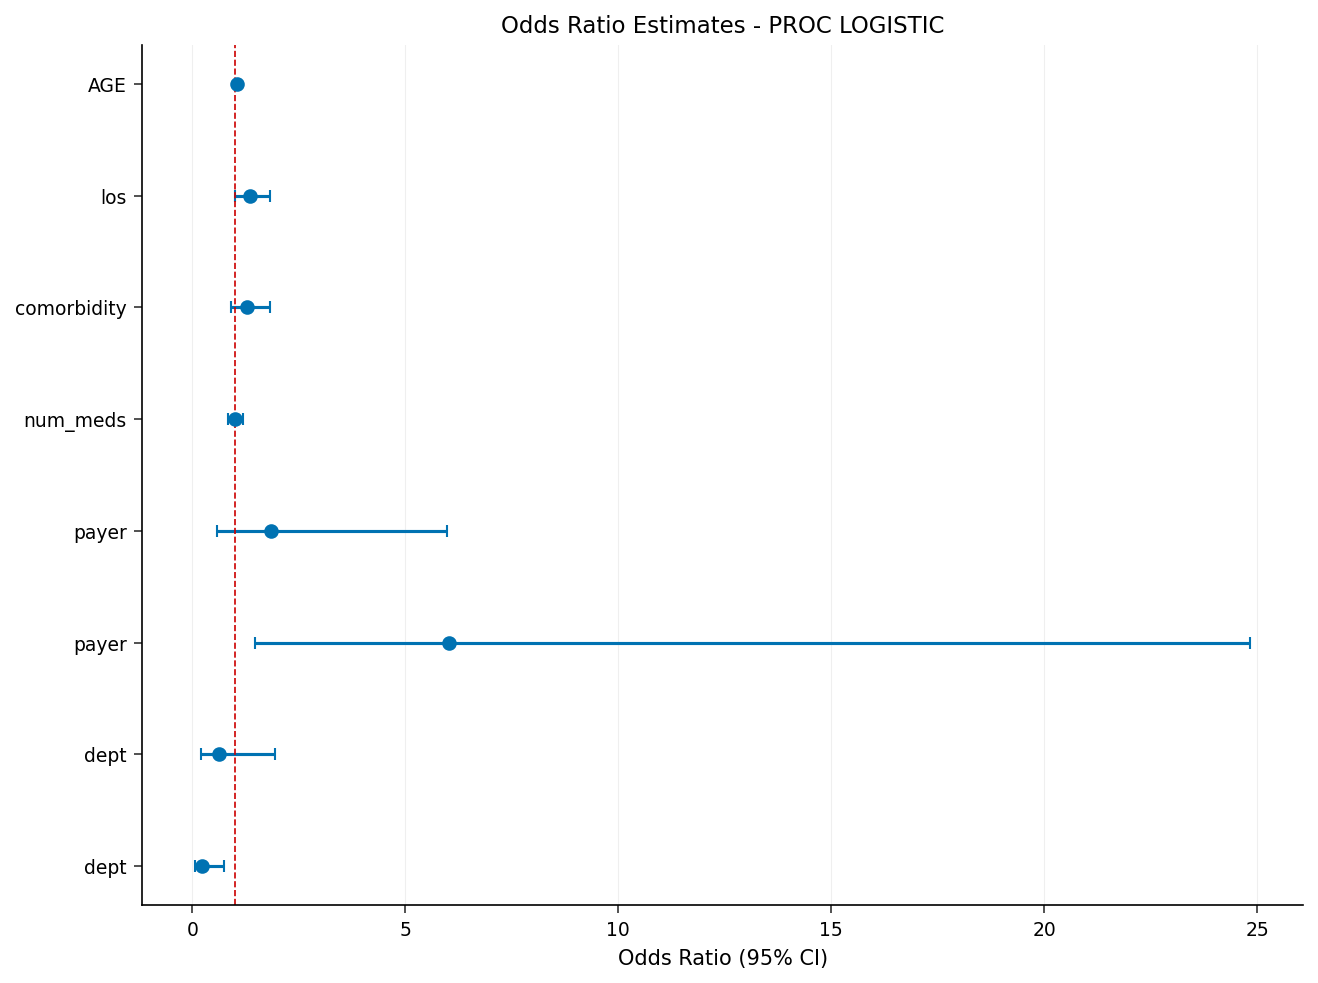

In [3]:
ODS UITVOER ParameterEstimates=pe;
PROCEDURE LOGISTIC GEGEVENS=encounters PLOTS(only)=oddsratio;
    KLASSE payer dept / PARAM=REF REF=first;
    MODEL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
UITVOEREN;
ODS UITVOER CLOSE;

## Stap 4 — De geschatte coëfficiënten vastleggen

De modelgebaseerde effectplots die volgen, zijn rechtstreeks opgebouwd uit de *geschatte* coëfficiënten, dus ze zijn altijd in overeenstemming met het model uit Stap 3. We hebben de parameterschattingen opgeslagen met `ODS OUTPUT ParameterEstimates=pe`; hier vouwen we die lange tabel om tot een `params`-dataset van één rij (één variabele per coëfficiënt) en voegen we de cohortgemiddelden van de continue voorspellers toe. Het vasthouden van de niet-focusvoorspellers op hun gemiddelde is precies wat een EFFECTPLOT intern doet — het laat elke plot één factor variëren terwijl de rest op een representatief profiel wordt vastgehouden.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
GEGEVENS coefs;
    BEHOUDEN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    INSTELLEN pe EINDE=last;
    VARIABELE = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    ALS VARIABELE='INTERCEPT' DAN b0 = ESTIMATE;
    ANDERS ALS VARIABELE='AGE' DAN b_age = ESTIMATE;
    ANDERS ALS VARIABELE='LOS' DAN b_los = ESTIMATE;
    ANDERS ALS VARIABELE='COMORBIDITY' DAN b_com = ESTIMATE;
    ANDERS ALS VARIABELE='NUM_MEDS' DAN b_med = ESTIMATE;
    ANDERS ALS VARIABELE='PAYER' AND cv='Medicaid'   DAN b_pmcaid = ESTIMATE;
    ANDERS ALS VARIABELE='PAYER' AND cv='Commercial' DAN b_pcomm  = ESTIMATE;
    ANDERS ALS VARIABELE='DEPT'  AND cv='Cardiology' DAN b_dcard  = ESTIMATE;
    ANDERS ALS VARIABELE='DEPT'  AND cv='General'    DAN b_dgen   = ESTIMATE;
    ALS last DAN UITVOER;
    BEWAREN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
UITVOEREN;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDURE GEMIDDELDEN GEGEVENS=encounters NOPRINT;
    VARIABELE AGE los comorbidity num_meds;
    UITVOER out=mn mean=m_age m_los m_com m_med;
UITVOEREN;

GEGEVENS params;
    SAMENVOEGEN coefs mn;
    BEWAREN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=params noobs;
    TITEL "Gefitte coefficienten en covariaatgemiddelden voor de effectplots";
UITVOEREN;

                           Gefitte coefficienten en covariaatgemiddelden voor de effectplots                            

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Stap 5 — Fit-plot: heropnamekans versus ligduur

De eenvoudigste effectweergave is een **fit curve**: voorspelde heropnamekans tegen één continue covariaat, met de overige voorspellers op een representatief profiel. We bouwen een ligduurraster (1–18 dagen), evalueren de geschatte lineaire predictor bij elke waarde voor een **Medicare-cardiologie**patiënt (leeftijd, comorbiditeit en aantal ontslagmedicijnen vastgezet op de cohortgemiddelden uit Stap 4), passen de inverse logit toe en tekenen de curve op de kansschaal met PROC SGPLOT.

                           Gefitte coefficienten en covariaatgemiddelden voor de effectplots                            




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


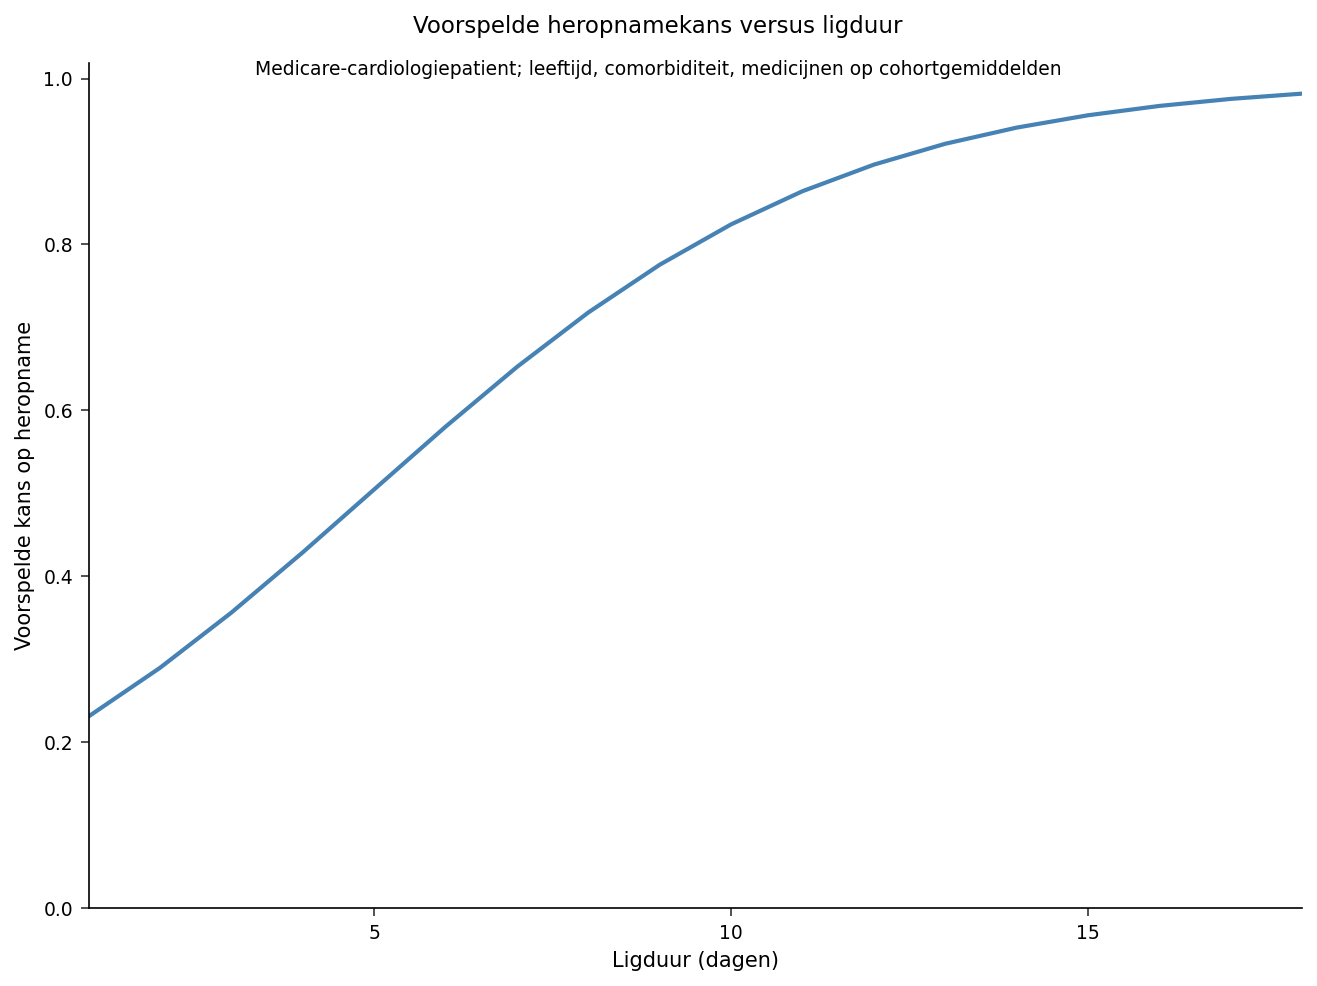

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
GEGEVENS grid_los;
    DOE los = 1 TOT 18;
        UITVOER;
    EINDE;
UITVOEREN;

GEGEVENS fit_los;
    INSTELLEN grid_los;
    ALS _n_ = 1 DAN INSTELLEN params;
    BEHOUDEN b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    BEWAREN los phat;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITEL  "Voorspelde heropnamekans versus ligduur";
    title2 "Medicare-cardiologiepatient; leeftijd, comorbiditeit, medicijnen op cohortgemiddelden";
    XAXIS label="Ligduur (dagen)";
    YAXIS label="Voorspelde kans op heropname" VALUES=(0 TOT 1 VOLGENS 0.2);
UITVOEREN;

## Stap 6 — Sliced fit: risico versus leeftijd, gestratificeerd naar betaler

Een **sliced fit** tekent één geschatte curve per niveau van een classificatie-effect — ideaal om te tonen hoe de betalermix de leeftijd–risicogradiënt verschuift. We breiden het raster uit over `age` (30–95) gekruist met de drie betalers, evalueren het geschatte model voor een Cardiology-patiënt (ligduur, comorbiditeit en medicijnen op de cohortgemiddelden) en leggen de drie kanscurves over elkaar met `GROUP=payer`.

                           Gefitte coefficienten en covariaatgemiddelden voor de effectplots                            




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


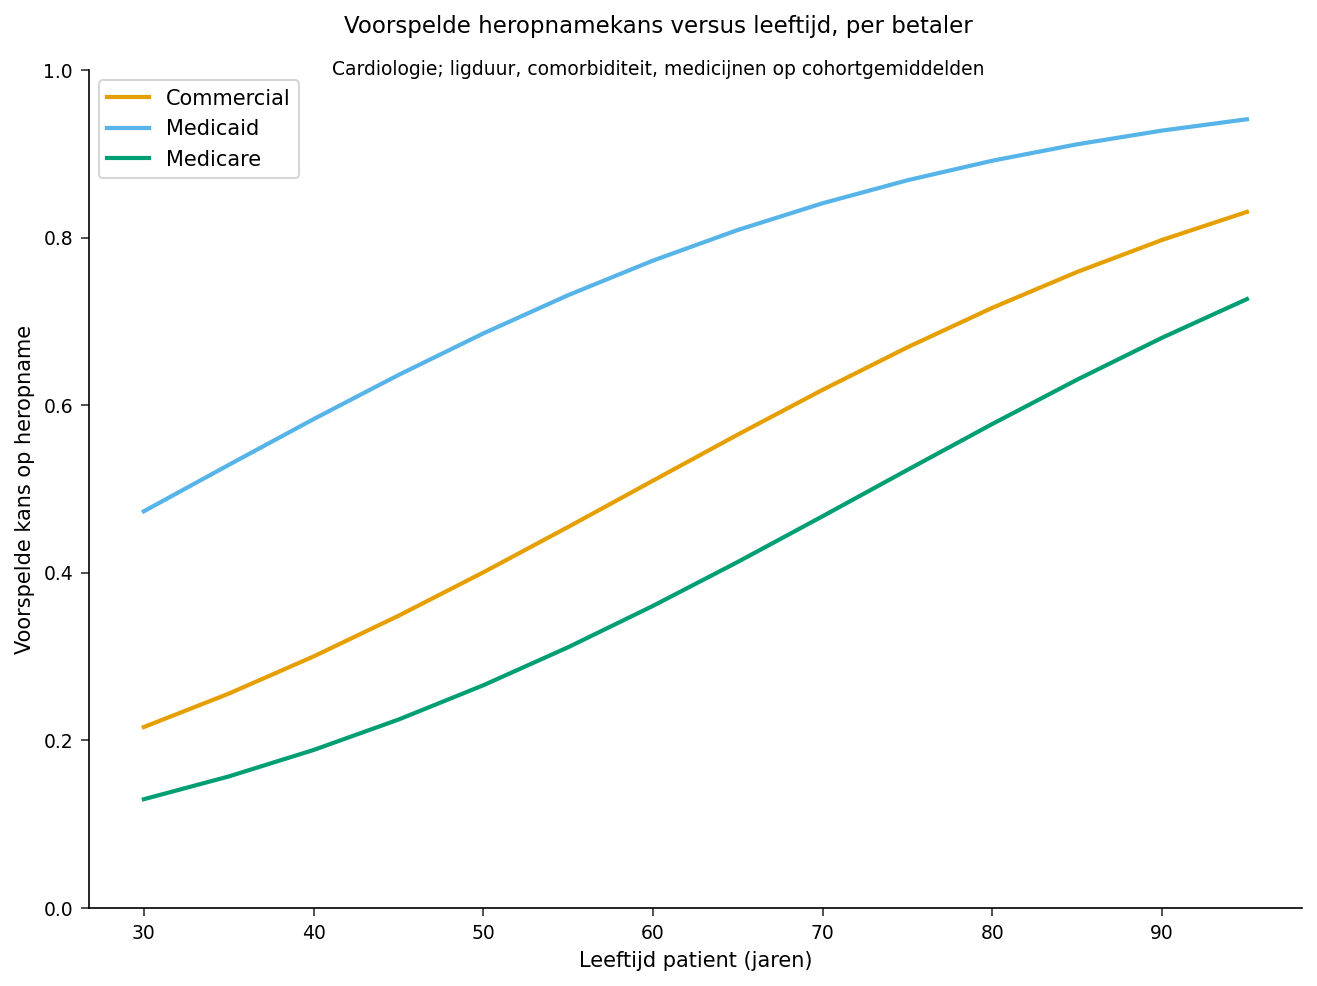

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
GEGEVENS grid_age;
    LENGTE payer $12;
    DOE payer = 'Medicare', 'Medicaid', 'Commercial';
        DOE AGE = 30 TOT 95 VOLGENS 5;
            UITVOER;
        EINDE;
    EINDE;
UITVOEREN;

GEGEVENS fit_age;
    INSTELLEN grid_age;
    ALS _n_ = 1 DAN INSTELLEN params;
    BEHOUDEN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    BEWAREN payer AGE phat;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITEL  "Voorspelde heropnamekans versus leeftijd, per betaler";
    title2 "Cardiologie; ligduur, comorbiditeit, medicijnen op cohortgemiddelden";
    XAXIS label="Leeftijd patient (jaren)";
    YAXIS label="Voorspelde kans op heropname" VALUES=(0 TOT 1 VOLGENS 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
UITVOEREN;

## Stap 7 — Interactieweergave: afdeling per betaler

Om het voorspelde risico over beide classificatie-effecten tegelijk te vergelijken, kruisen we `dept` met `payer` (negen combinaties), evalueren we het geschatte model met elke continue covariaat op het cohortgemiddelde, en tekenen we een geclusterd staafdiagram met `dept` op de X-as en betaler als groepering. Omdat dit model geen interactieterm van afdeling en betaler bevat, is de betalervolgorde dezelfde additieve verschuiving binnen elke afdeling — de weergave maakt die additiviteit in één oogopslag zichtbaar, naast de rangschikking van afdelingen.

                           Gefitte coefficienten en covariaatgemiddelden voor de effectplots                            




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


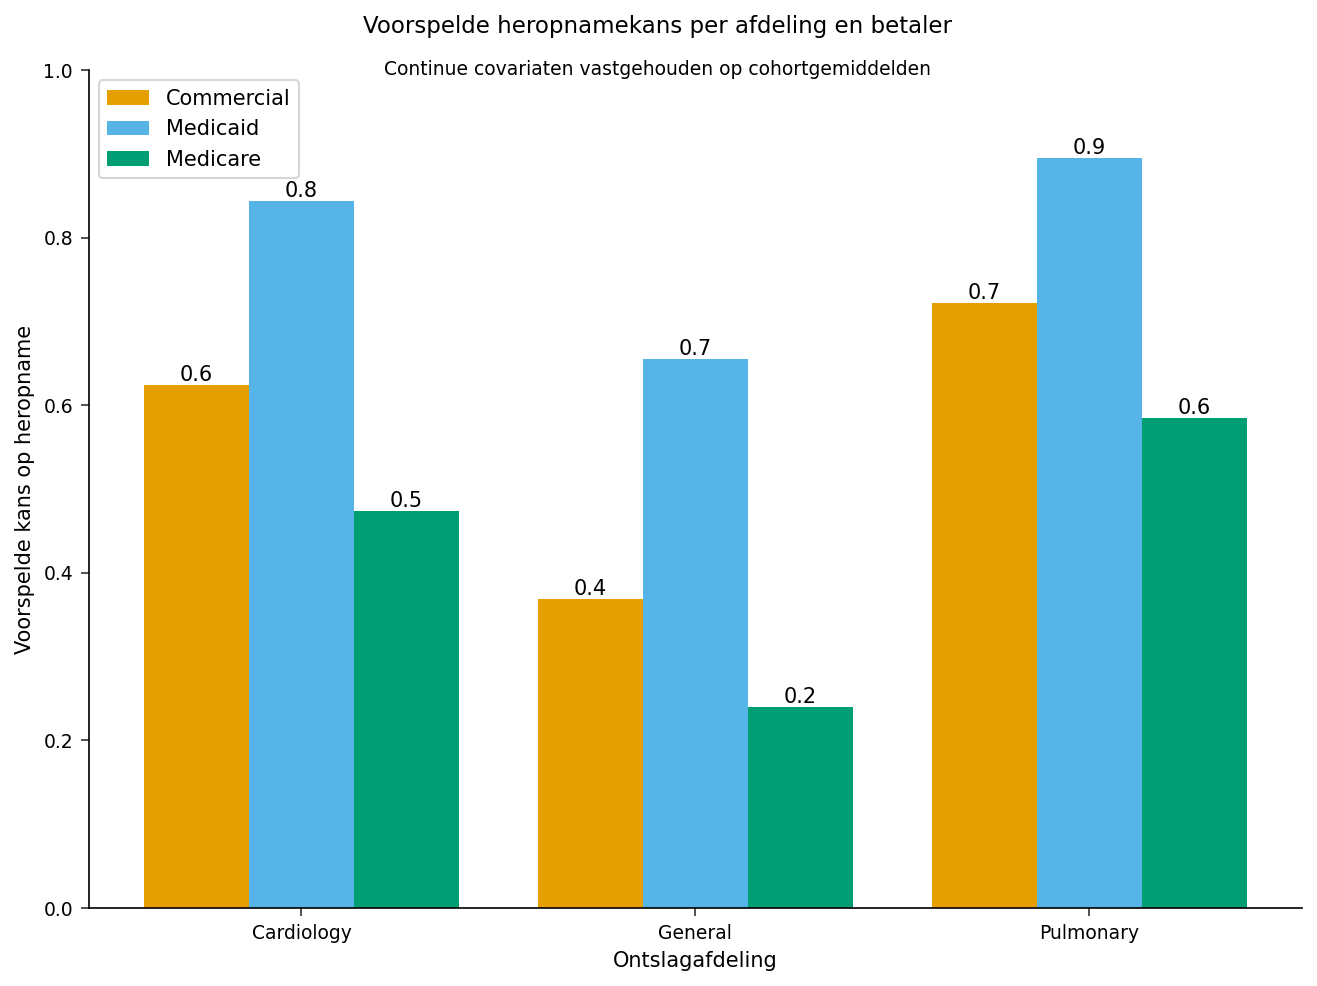

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
GEGEVENS grid_dx;
    LENGTE dept $12 payer $12;
    DOE dept = 'Cardiology', 'Pulmonary', 'General';
        DOE payer = 'Medicare', 'Medicaid', 'Commercial';
            UITVOER;
        EINDE;
    EINDE;
UITVOEREN;

GEGEVENS fit_dx;
    INSTELLEN grid_dx;
    ALS _n_ = 1 DAN INSTELLEN params;
    BEHOUDEN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    BEWAREN dept payer phat;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITEL  "Voorspelde heropnamekans per afdeling en betaler";
    title2 "Continue covariaten vastgehouden op cohortgemiddelden";
    XAXIS label="Ontslagafdeling";
    YAXIS label="Voorspelde kans op heropname" VALUES=(0 TOT 1 VOLGENS 0.2);
UITVOEREN;

## Stap 8 — De resultaten interpreteren

De effectplots zetten het geschatte PROC LOGISTIC-model om in beelden op de kansschaal die aansluiten op zorgmanagementbeslissingen:

- **Ligduur (fit curve).** Voor een Medicare-cardiologiepatiënt op de cohortgemiddelden stijgt de voorspelde heropnamekans van ongeveer **0.23 bij een opname van 1 dag tot ruwweg 0.82 bij 10 dagen en ~0.98 bij 18 dagen** — het steile midden van de logistische curve. Dit is hetzelfde signaal als de odds ratio van **1.36 per dag** voor ligduur (`UNITS los=5` schaalt die om naar een stap van vijf dagen), en het markeert lange indexopnames als een concrete aanleiding voor inschrijving in transitiezorg.
- **Leeftijd en betaler (sliced fit).** Het risico stijgt monotoon met de leeftijd bij elke betaler, en de drie curves kruisen elkaar nooit: de **Medicaid**-curve ligt bij elke gegeven leeftijd het hoogst, **Commercial** in het midden en **Medicare** het laagst — in overeenstemming met de geschatte betaler-odds-ratio's (Medicaid 6.02, Commercial 1.85, beide ten opzichte van Medicare). Het verschil is het grootst op jongere leeftijd en wordt kleiner naarmate iedereen een hoge kans nadert, wat de aandacht van het zorgmanagement richt op jongere Medicaid-patiënten die er anders laag-risico zouden uitzien.
- **Afdeling en betaler (interactieweergave).** **Pulmonary** draagt in elke betalergroep de hoogste voorspelde heropnamekans, **Cardiology** zit ertussenin en **General medicine** het laagst (de geschatte afdelings-odds-ratio's zijn 0.64 voor Cardiology en 0.22 voor General, ten opzichte van Pulmonary). Omdat het model geen interactieterm van afdeling en betaler bevat, is de betalervolgorde dezelfde additieve verschuiving binnen elke afdeling — de staven stijgen in elke afdeling in dezelfde volgorde Medicaid > Commercial > Medicare.

**Kernboodschap:** in plaats van clinici te vragen log-oddscoëfficiënten te interpreteren, presenteren modelgebaseerde effectplots het geschatte heropnamemodel als beelden op de kansschaal — wie in te schrijven voor transitiezorg-nazorg, en welke afdelingen en betalerpopulaties prioriteit te geven. SAS produceert deze rechtstreeks via `EFFECTPLOT`; hier hebben we de identieke curves gereconstrueerd uit de geschatte coëfficiënten zodat het voorbeeld vandaag volledig uitvoerbaar is.